In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib import colors
from skimage.feature import peak_local_max
from scipy.signal import find_peaks
import os
import pandas as pd
from skimage.filters import threshold_multiotsu

## Load dataset

In [20]:
stain_path = r'tonguedataset\Stain'
nonstain_path = r'tonguedataset\Non Stain'

def load_image_unicode(path):
    stream = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(stream, cv2.IMREAD_COLOR)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def resize_image(img, max_size=512):
    """Resize image so the longest side is max_size, maintaining aspect ratio."""
    h, w = img.shape[:2]
    scale = max_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

def load_images_range(folder, start=100, end=200, max_size=256):
    files = sorted(
        [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    )[start:end]

    images, names = [], []
    for name in files:
        img_path = os.path.join(folder, name)
        img = load_image_unicode(img_path)
        if img is not None:
            img = resize_image(img, max_size=max_size)
            images.append(img)
            names.append(name)
    return images, names


stain_images, stain_names = load_images_range(stain_path, 100, 200, max_size=512)
nonstain_images, nonstain_names = load_images_range(nonstain_path, 100, 200, max_size=512)

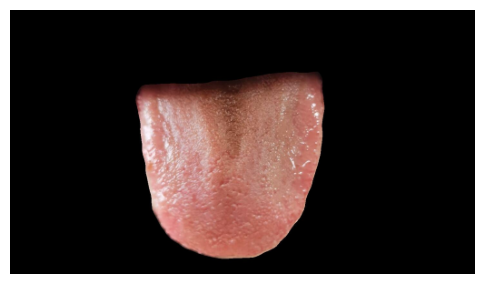

In [26]:
seg_img = stain_images[47]

# Display the segmented image
plt.figure(figsize=(6, 6))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


In [50]:
# --- Draw rectangle safely ---
def draw_colored_rectangle(img, coords, color):
    if len(img.shape) == 2:  # grayscale → RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = img.copy()
    y1, y2, x1, x2 = coords
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 1)
    return img_rgb


def get_subregions_with_border(img, subregions, colors):
    sub_imgs = []
    for (coords, color) in zip(subregions, colors):
        y1, y2, x1, x2 = coords
        y1, y2 = sorted((y1, y2))
        x1, x2 = sorted((x1, x2))
        y2 = min(y2, img.shape[0])
        x2 = min(x2, img.shape[1])
        sub_img = img[y1:y2, x1:x2].copy()
        if sub_img.size == 0:
            continue
        height, width = sub_img.shape[:2]
        sub_img = draw_colored_rectangle(sub_img, (0, height-1, 0, width-1), color)
        sub_imgs.append(sub_img)
    return sub_imgs

In [32]:
stain_names

['18_橙子.JPG',
 '190_咖啡.JPG',
 '191_芒果.JPG',
 '192_彩虹糖.JPG',
 '193_橘子.JPG',
 '194_金嗓子润喉糖.JPG',
 '195_桑葚.JPG',
 '196_橙子.JPG',
 '197_红心火龙果.JPG',
 '198_芒果.JPG',
 '199_蜂蜜.JPG',
 '19_巧克力.JPG',
 '1_咖啡.JPG',
 '200_黑巧.JPG',
 '201_红心火龙果.JPG',
 '202_橘子.JPG',
 '203_可口可乐.JPG',
 '204_可口可乐.JPG',
 '205_黑巧.JPG',
 '206_火龙果.JPG',
 '207_蓝莓.JPG',
 '208_蓝莓.JPG',
 '209_蓝莓.JPG',
 '20_奶糖.JPG',
 '210_芒果.JPG',
 '211_芒果.JPG',
 '212_咖啡味棒棒糖.JPG',
 '213_冰淇淋.JPG',
 '214_彩虹糖.JPG',
 '215_巧克力.JPG',
 '216_椰子灰甜筒.JPG',
 '217_橘子味糖果.JPG',
 '218_橘子味芬达.JPG',
 '219_柠檬糖.JPG',
 '21_彩虹糖.JPG',
 '220_葡萄味糖.JPG',
 '221_椰子灰冰淇淋.JPG',
 '222_咖啡味糖果.JPG',
 '223_椰子灰冰淇淋.JPG',
 '224_椰子灰冰淇淋.JPG',
 '225_橘子味糖果.JPG',
 '226_椰子灰冰淇淋.JPG',
 '227_彩虹糖.JPG',
 '228_彩虹糖.JPG',
 '229_芬达.JPG',
 '22_黑巧.JPG',
 '230_彩虹糖.JPG',
 '231_德芙巧克力.JPG',
 '232_德芙巧克力.JPG',
 '233_芬达汽水.JPG',
 '234_黄色彩虹糖.JPG',
 '235_巧乐兹雪糕.JPG',
 '236_巧克力.JPG',
 '237_黑巧.JPG',
 '238_芬达汽水.JPG',
 '239_橘子味糖果.JPG',
 '23_蓝莓干.JPG',
 '240_柠檬味糖果.JPG',
 '241_巧克力冰淇淋.JPG',
 '242_红心火龙果.JPG',
 '243_芒果.JPG',


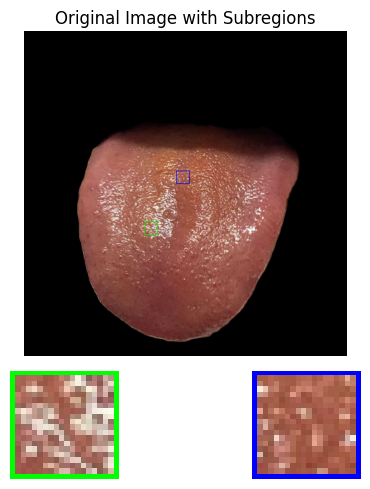

In [87]:
subregions = [(300, 320, 190, 210), (220, 240, 240, 260)]  # y1,y2,x1,x2
colors = [(0, 255, 0), (0, 0, 255)]  # green, blue

# Draw rectangles on a copy
img_boxed = stain_images[49].copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(stain_images[49], subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Original Image with Subregions")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Helper functions

In [44]:
def filter(max_val, min_val, alpha):
    if min_val>0:
        ratio = max_val / (min_val + 1e-5)
        return alpha * pow(ratio, alpha) + math.log(ratio)
    return 0.0

def EMME(img, kernel=3, alpha=1.0):
    h, w = img.shape
    EMME_val = 0.0

    # Step size kernel, cover entire image
    count = 0
    for i in range(0, h, kernel):
        for j in range(0, w, kernel):
            window = img[i:i+kernel, j:j+kernel]
            if window.size == 0:
                continue
            max_val = np.max(window)
            min_val = np.min(window)
            EMME_val += filter(max_val, min_val, alpha)
            count += 1

    if count > 0:
        EMME_val /= count
    return EMME_val

def PSNR(img1, img2):
    img1 = np.array(img1, dtype=np.float64)
    img2 = np.array(img2, dtype=np.float64)
    mse = np.mean((img1 - img2) ** 2)

    if mse == 0:
        return float('inf')
    
    L = 255.0
    PSNR =  10 * math.log10((L ** 2) / mse)
    return PSNR


def median_filter(image, kernel_size):
    h, w = image.shape

    pad = kernel_size // 2
    padded_img = np.pad(image, pad, mode='edge')
    img_new = np.zeros((h, w), dtype=float)

    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()
            new_pixel = np.median(window)
            img_new[i, j] = new_pixel
    img_new = np.clip(img_new, 0, 255).astype(np.uint8)
    return img_new

def weighted_median(image, kernel_size):
    if kernel_size == 3:
        weights = np.array([[1, 2, 1],
                            [2, 3, 2],
                            [1, 2, 1]])
    elif kernel_size == 5:
        weights = np.array([[1, 1, 2, 1, 1],
                            [1, 2, 3, 2, 1],
                            [2, 3, 4, 3, 2],
                            [1, 2, 3, 2, 1],
                            [1, 1, 2, 1, 1]])
    h, w = image.shape
    pad = kernel_size // 2
    padded_img = np.pad(image, pad, mode='edge')
    img_new = np.zeros((h, w), dtype=float)

    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+kernel_size, j:j+kernel_size]
            new_window = np.repeat(window.flatten(), weights.flatten())
            new_pixel = np.median(new_window)
            img_new[i, j] = new_pixel
    img_new = np.clip(img_new, 0, 255).astype(np.uint8)
    return img_new

def clahe_image(img, clip=40.0, size=8):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(size,size))
    cl1 = clahe.apply(img)
    return cl1

def gamma_correction(img, gamma):
    img_normalized = img / 255.0

    transformed = np.power(img_normalized, gamma)
    transformed = np.uint8(transformed * 255)
    
    return transformed

def img_enhancement(img):
    img = img.astype(np.uint8)
    orig_rgb = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # --------  Median / Weighted Median --------
    median_methods = {}
    for w in [3, 5, 7]:
        median_methods[f'median_{w}'] = median_filter(gray, w)
    for w in [3, 5]:
        median_methods[f'weighted_median_{w}'] = weighted_median(gray, w)

    # Pick the one with highest PSNR
    best_psnr = -np.inf
    best_method_name_stage1 = 'none'
    best_img_stage1 = None
    for name, candidate in median_methods.items():
        score = PSNR(gray, candidate)
        if score > best_psnr:
            best_psnr = score
            best_method_name_stage1 = name
            best_img_stage1 = candidate

    # -------- Use filtered image if PSNR >= 30, else original --------
    stage2_input = best_img_stage1 if best_psnr >= 30 else gray
    stage1_used = best_method_name_stage1 if best_psnr >= 30 else 'none'

    # -------- Apply CLAHE / Gamma and choose best by EMME --------
    methods = {}

    # CLAHE
    for i in range(1, 9):
        new_img = clahe_image(stage2_input, clip=i)
        emme_val = EMME(new_img)
        methods[f'clahe_clip_{i}'] = (new_img, emme_val)

    # Gamma correction
    for g in [0.8, 1.2, 1.5]:
        new_img = gamma_correction(stage2_input, g)
        emme_val = EMME(new_img)
        methods[f'gamma_{g}'] = (new_img, emme_val)

    # Pick the best method based on EMME
    best_emme = -np.inf
    best_stage2_name = None
    best_img = stage2_input  # fallback to stage2_input
    for name, (candidate, score) in methods.items():
        if score > best_emme:
            best_emme = score
            best_stage2_name = name
            best_img = candidate

    # Combine Stage 1 + Stage 2 for final method name
    best_method_name = f"{stage1_used}+{best_stage2_name}"

    # -------- Apply enhancement in HSV space --------
    hsv = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Apply the same best enhancement method to S channel
    if best_stage2_name.startswith('clahe_clip_'):
        clip_val = int(best_stage2_name.split('_')[-1])
        s_filtered = clahe_image(s, clip=clip_val)
    elif best_stage2_name.startswith('gamma_'):
        gamma_val = float(best_stage2_name.split('_')[-1])
        s_filtered = gamma_correction(s, gamma_val)
    else:
        # fallback in case of 'none' or unexpected
        s_filtered = median_filter(s, 3)

    v_enhanced = best_img

    hsv_enhanced = cv2.merge([h, s_filtered, v_enhanced])
    rgb_enhanced = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

    return rgb_enhanced, best_method_name


# ------------------------------------------------------------------------


def extract_hsv(img):
        hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv) 
        img = 255 - s 
        return img

def Sauvola(img, window_size=15, k=0.35, R=0.5):
    # Normalize image to 0–1
    img = img.astype(np.float32) / 255.0

    # Compute local mean and standard deviation
    mean = cv2.boxFilter(img, ddepth=-1, ksize=(window_size, window_size))
    mean_sq = cv2.boxFilter(img**2, ddepth=-1, ksize=(window_size, window_size))
    std = np.sqrt(mean_sq - mean**2)

    # Compute Sauvola threshold
    threshold = mean * (1 + k * (std / R - 1))

    # Apply threshold
    output = (img > threshold).astype(np.uint8) * 255

    return output

def local_adaptive(img, window_size=15, weight=0.5):
    # sliding window
    # calculate local mean of the window
    # if the pixel values are uniformed, make 0 or 1 based on local mean
    # if pixel greater than threshold, pixel = 1, else pixel = 0
    # threshold = weight * [local_mean + (local max pixel - local minimum pixel)/global max pixel]
    half = window_size // 2
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.uint8)

    global_max = np.max(img)

    # Pad image to handle edges
    padded = np.pad(img, pad_width=half, mode='reflect')

    for i in range(h):
        for j in range(w):
            # Extract local window
            local_window = padded[i:i+window_size, j:j+window_size]
            local_mean = np.mean(local_window)
            local_max = np.max(local_window)
            local_min = np.min(local_window)

            # Calculate adaptive threshold
            threshold = weight * (local_mean + (local_max - local_min) / (global_max + 1e-8))

            # Apply threshold
            if img[i, j] > threshold:
                output[i, j] = 1
            else:
                output[i, j] = 0

    return output        


def NiBlack(img, window_size=3, k=-0.2):
    mean = cv2.boxFilter(img, ddepth=-1, ksize=(window_size, window_size))
    mean_sq = cv2.boxFilter(img**2, ddepth=-1, ksize=(window_size, window_size))
    std = np.sqrt(mean_sq - mean**2)

    # Niblack threshold
    threshold = mean + k * std

    # Apply threshold
    output = (img > threshold).astype(np.uint8) * 255
    return output

from skimage.measure import label, regionprops
def img_segmentation(img, method):
    method = method.lower()  # convert to lowercase

    img_s = extract_hsv(img)
    if method == 'global':
        # First separate tongue from background
        N, M = img_s.shape

        T_new = np.sum(img_s) / (N * M)
        segmented = np.where(img_s >= T_new, 255, 0).astype(np.uint8)

    elif method == 'sauvola':
        segmented = Sauvola(img_s, window_size=3, k=0.35)

    elif method == 'local':
        segmented = local_adaptive(img_s, window_size=15, weight=2.0)

    elif method == 'niblack':
        segmented = NiBlack(img_s, window_size=15, k=-0.2)

    elif method == 'otsu':
        thresholds = threshold_multiotsu(img_s, classes=2)
        regions = np.digitize(img_s, bins=thresholds)
        segmented = (regions * (255 // regions.max())).astype(np.uint8)

    else:
        raise ValueError(f"Unknown segmentation method: {method}")

    # --- Apply mask to RGB image ---
    mask_bool = segmented > 0
    result_rgb = np.zeros_like(img)
    for c in range(3):
        result_rgb[..., c] = img[..., c] * mask_bool

    return result_rgb

# ------------------------------------------------------------------------------------

def histogram_features(img):
    hist, bins = np.histogram(img.ravel(), bins=256, range=(0, 255))

    return hist

def produce_label(h1, h2):
    h1, h2 = np.asarray(h1), np.asarray(h2)

    # Chi-squared distance 
    chi = 0.5 * np.sum(((h1 - h2) ** 2) / (h1 + h2 + 1e-10))

    # Correlation coefficient 
    h1_mean, h2_mean = np.mean(h1), np.mean(h2)
    num = np.sum((h1 - h1_mean) * (h2 - h2_mean))
    den = np.sqrt(np.sum((h1 - h1_mean)**2) * np.sum((h2 - h2_mean)**2))
    corr = num / (den + 1e-10)

    # Histogram intersection 
    inter = np.sum(np.minimum(h1, h2)) / (np.sum(h2) + 1e-10)

    return {"chi": chi, "corr": corr, "inter": inter}

def cal_accuracy(pred,actual):
    correct = np.sum(np.array(pred) == np.array(actual))
    accuracy = correct/len(actual)*100
    print(accuracy)

# ----------------------------------------------------------------------------------------

## Image Enhancement

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def enhance_images(images, image_names=None, save_dir=None, prefix="enhanced_", n_jobs=10):

    results = [None] * len(images)
    method_names = [None] * len(images)
    with ThreadPoolExecutor(max_workers=n_jobs) as executor:
        futures = {executor.submit(img_enhancement, img): i for i, img in enumerate(images)}
        for future in tqdm(as_completed(futures), total=len(images), desc="Enhancing images", dynamic_ncols=True):
            i = futures[future]
            enhanced_img, method_name = future.result()
            results[i] = enhanced_img
            method_names[i] = method_name

            if save_dir is not None and image_names is not None:
                os.makedirs(save_dir, exist_ok=True)
                base_name = os.path.splitext(os.path.basename(image_names[i]))[0]
                save_path = os.path.join(save_dir, f"{prefix}{base_name}_{method_name}.png")
                cv2.imwrite(save_path, cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR))

    return results, method_names



# Run enhancement
stain_images, stain_methods = enhance_images(stain_images, stain_names, save_dir="enhanced_stain")
df = pd.DataFrame({
    "image_index": range(len(stain_methods)),
    "best_method": stain_methods
})
df.to_csv("enhanced_stain/method_summary.csv", index=False)

Enhancing images: 100%|██████████| 100/100 [56:21<00:00, 33.82s/it] 


In [5]:
nonstain_images, nonstain_methods = enhance_images(nonstain_images, nonstain_names, save_dir="enhanced_nonstain")
df = pd.DataFrame({
    "image_index": range(len(nonstain_methods)),
    "best_method": nonstain_methods
})
df.to_csv("enhanced_nonstain/method_summary.csv", index=False)

Enhancing images: 100%|██████████| 100/100 [41:05<00:00, 24.65s/it] 


In [29]:
stain_path = r'enhanced_stain'
nonstain_path = r'enhanced_nonstain'

def load_image_unicode(path):
    try:
        with open(path, 'rb') as f:
            data = f.read()
        img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return None

def load_images_from_folder(folder, exts=('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
    images = []
    for filename in sorted(os.listdir(folder)):
        path = os.path.join(folder, filename)
        if os.path.isfile(path) and filename.lower().endswith(exts):
            img = load_image_unicode(path)
            if img is not None:
                images.append(img)
            else:
                print(f"Skipped unreadable: {filename}")
    print(f"✅ Loaded {len(images)} images from {folder}")
    return images
stain_images = load_images_from_folder(stain_path)
nonstain_images = load_images_from_folder(nonstain_path)

✅ Loaded 100 images from enhanced_stain
✅ Loaded 100 images from enhanced_nonstain


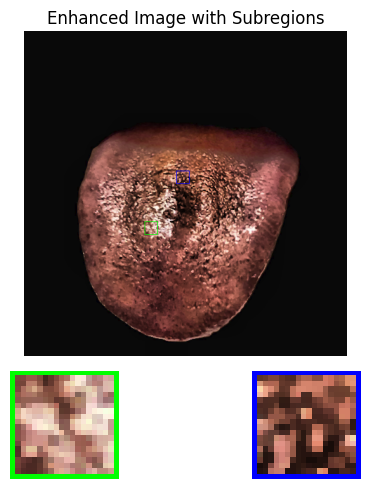

In [89]:
subregions = [(300, 320, 190, 210), (220, 240, 240, 260)]  # y1,y2,x1,x2
colors = [(0, 255, 0), (0, 0, 255)]  # green, blue


# Draw rectangles on a copy
img_boxed = stain_images[49].copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(stain_images[49], subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Enhanced Image with Subregions")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
subregions = [(120, 140, 220, 240), (220, 240, 240, 260)]  # y1,y2,x1,x2
colors = [(0, 255, 0), (0, 0, 255)]  # green, blue

# Draw rectangles on a copy
img_boxed = stain_images[47].copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(stain_images[47], subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Original Image with Subregions")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Image Segmentation

In [30]:
stain_segments = []
nonstain_segments = []

# Segment images
for img in stain_images:
    seg = img_segmentation(img, method="otsu")
    stain_segments.append(seg)

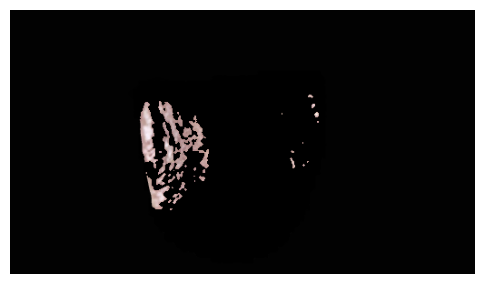

In [27]:
# Unpack the tuple
seg_img = stain_segments[47]

# Display the segmented image
plt.figure(figsize=(6, 6))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# Print the S_quantity score
#print(score)

In [49]:
for img in nonstain_images:
    seg = img_segmentation(img, method='otsu')
    nonstain_segments.append(seg)

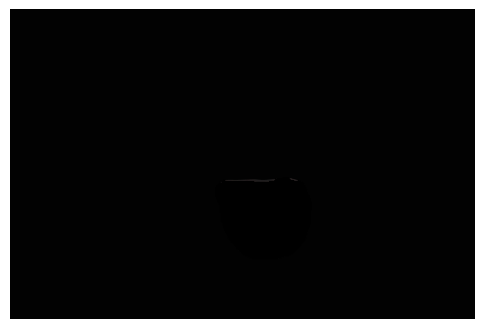

In [52]:
# Unpack the tuple
seg_img = nonstain_segments[50]

# Display the segmented image
plt.figure(figsize=(6, 6))
plt.imshow(seg_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## Image Histogram

-Identify the tongue marks to store

In [32]:
stain_features = []
nonstain_features = []

for img in stain_segments:
    feats = histogram_features(img)
    stain_features.append(feats)

for img in nonstain_segments:
    feats = histogram_features(img)
    nonstain_features.append(feats)

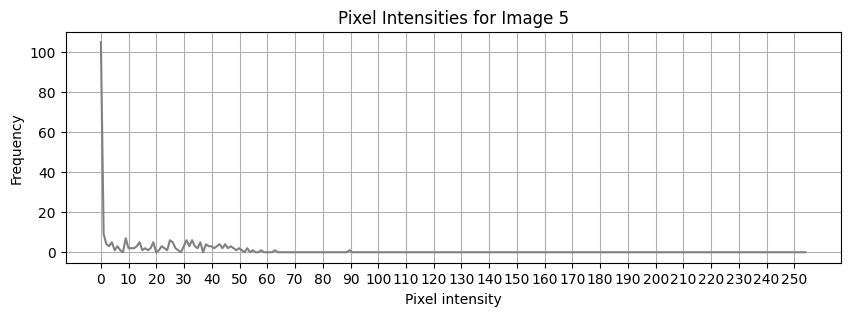

In [9]:
hist, bins = np.histogram(stain_features[5].ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Pixel Intensities for Image 5")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

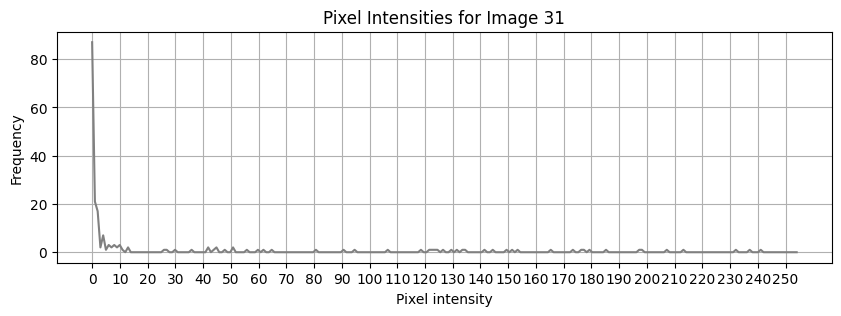

In [10]:
hist, bins = np.histogram(stain_features[31].ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Pixel Intensities for Image 31")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

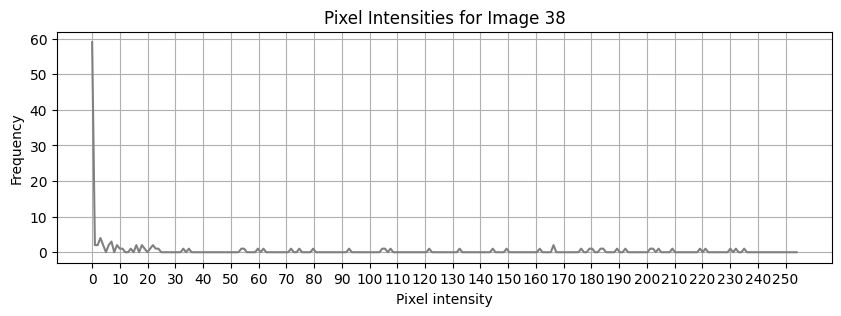

In [11]:
hist, bins = np.histogram(stain_features[38].ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Pixel Intensities for Image 38")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

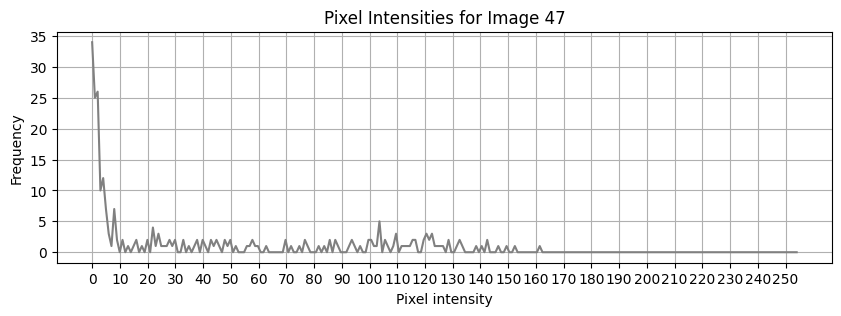

In [12]:
hist, bins = np.histogram(stain_features[47].ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Pixel Intensities for Image 47")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

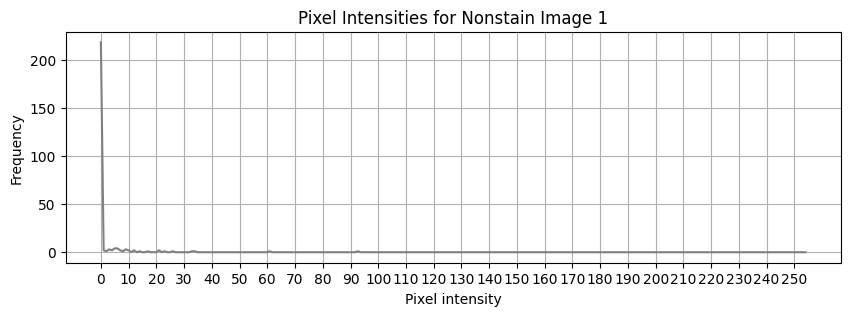

In [51]:
hist, bins = np.histogram(nonstain_features[50].ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Pixel Intensities for Nonstain Image 1")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

## Histogram Similarity

In [13]:
from sklearn.model_selection import train_test_split

X = stain_features + nonstain_features
y = [1] * len(stain_features) + [0] * len(nonstain_features)  # 1=stain, 0=nonstain

segments = stain_segments + nonstain_segments

# Split 85% train / 15% test
X_train, X_test, y_train, y_test, seg_train, seg_test = train_test_split(
    X, y, segments, test_size=0.15, random_state=1, stratify=y)

In [14]:
y_pred = []

for x in X_test:
    best_score = -float('inf')
    best_label = None

    for i, train_feat in enumerate(X_train):
        scores = produce_label(x, train_feat)

        # Combine the metrics:
        combined_score = (scores["corr"] + scores["inter"]) - scores["chi"]

        if combined_score > best_score:
            best_score = combined_score
            best_label = y_train[i]

    y_pred.append(best_label)

## Accuracy

In [15]:
print(f"Accuracy:")
cal_accuracy(y_pred,y_test)

Accuracy:
100.0
